# uber user data analysis project

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# After importing libraries we we will load and read the dataset by using pandas

df = pd.read_excel("UberDataset.xlsx")

In [4]:
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,2016-02-01 01:25:00,2016-02-01 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,2016-02-01 20:25:00,2016-02-01 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,2016-05-01 17:31:00,2016-05-01 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,2016-06-01 14:42:00,2016-06-01 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


we can see that there are 1156 rows in the dataset

# We will understand the dataset

___________________________________________________________________________________________________________________

In [5]:
# Finding the shape of dataset

df.shape

(1156, 7)

In [6]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


Here information function tell about dataset that column-0, and column-5 does not contain null value but column-1,2,3,4 contain one null value and column-6 contain only 653 non-null value means it contained 500+ null value.

START_DATE and END_DATE is in the object datatype

In [7]:
df.columns  # this shows the columns name that have in dataset

Index(['START_DATE', 'END_DATE', 'CATEGORY', 'START', 'STOP', 'MILES',
       'PURPOSE'],
      dtype='object')

__________________________________________________________________________________________________

# Data preprocessing

In [8]:
# now we will replace the Null value PURPOSE column with 'NOT'.

df["PURPOSE"].fillna("NOT", inplace = True)

C:\Users\niraj\AppData\Local\Temp\ipykernel_20872\2510771572.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["PURPOSE"].fillna("NOT", inplace = True)


In [9]:
df.head(3)

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,2016-02-01 01:25:00,2016-02-01 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT
2,2016-02-01 20:25:00,2016-02-01 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies


# Now we will change the data type of date

In [10]:
# errors = 'coerce'  means Agar kisi value ko date mein convert nahi kiya ja sakta, to error dene ke bajay us value ko NaT bana do

df['START_DATE'] = pd.to_datetime(df['START_DATE'], errors = 'coerce')

df['END_DATE'] = pd.to_datetime(df['END_DATE'], errors = 'coerce')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   START_DATE  1155 non-null   datetime64[ns]
 1   END_DATE    1155 non-null   datetime64[ns]
 2   CATEGORY    1155 non-null   object        
 3   START       1155 non-null   object        
 4   STOP        1155 non-null   object        
 5   MILES       1156 non-null   float64       
 6   PURPOSE     1156 non-null   object        
dtypes: datetime64[ns](2), float64(1), object(4)
memory usage: 63.3+ KB


In [12]:
# Adding two column 'date' and 'time'

from datetime import datetime

df["date"] = pd.DatetimeIndex(df['START_DATE']).date
df['time'] = pd.DatetimeIndex(df['START_DATE']).hour

In [13]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,date,time
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0
1,2016-02-01 01:25:00,2016-02-01 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-02-01,1.0
2,2016-02-01 20:25:00,2016-02-01 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-02-01,20.0
3,2016-05-01 17:31:00,2016-05-01 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-05-01,17.0
4,2016-06-01 14:42:00,2016-06-01 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-06-01,14.0


# On the basis of time we will categorize the time by pd.cut() function and add the column 'day-night'

In [14]:
df['day-night'] = pd.cut(
    x=df['time'],
    bins=[0, 10, 15, 19, 24],
    labels=['Morning', 'Afternoon', 'Evening', 'Night']
)

In [15]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,date,time,day-night
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,Night
1,2016-02-01 01:25:00,2016-02-01 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-02-01,1.0,Morning
2,2016-02-01 20:25:00,2016-02-01 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-02-01,20.0,Night
3,2016-05-01 17:31:00,2016-05-01 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-05-01,17.0,Evening
4,2016-06-01 14:42:00,2016-06-01 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-06-01,14.0,Afternoon


In [16]:
# Checking the dataset shape

df.shape

(1156, 10)

In [17]:
# If i drop null value then shape :

df.dropna(inplace = True)

In [18]:
df.shape

(1136, 10)

In [19]:
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,date,time,day-night
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,Night
1,2016-02-01 01:25:00,2016-02-01 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-02-01,1.0,Morning
2,2016-02-01 20:25:00,2016-02-01 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-02-01,20.0,Night
3,2016-05-01 17:31:00,2016-05-01 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-05-01,17.0,Evening
4,2016-06-01 14:42:00,2016-06-01 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-06-01,14.0,Afternoon
...,...,...,...,...,...,...,...,...,...,...
1150,2016-12-31 01:07:00,2016-12-31 01:14:00,Business,Kar?chi,Kar?chi,0.7,Meeting,2016-12-31,1.0,Morning
1151,2016-12-31 13:24:00,2016-12-31 13:42:00,Business,Kar?chi,Unknown Location,3.9,Temporary Site,2016-12-31,13.0,Afternoon
1152,2016-12-31 15:03:00,2016-12-31 15:38:00,Business,Unknown Location,Unknown Location,16.2,Meeting,2016-12-31,15.0,Afternoon
1153,2016-12-31 21:32:00,2016-12-31 21:50:00,Business,Katunayake,Gampaha,6.4,Temporary Site,2016-12-31,21.0,Night


All dala is analyzeable now because i added 3 more column date, time, and day-night.

____________________________________________________________________________________________________________________________

# Data Visulaization

# Q-1)  Which type of category choosed the users ?

# Q-2) By the user, max uber was used for which category ?

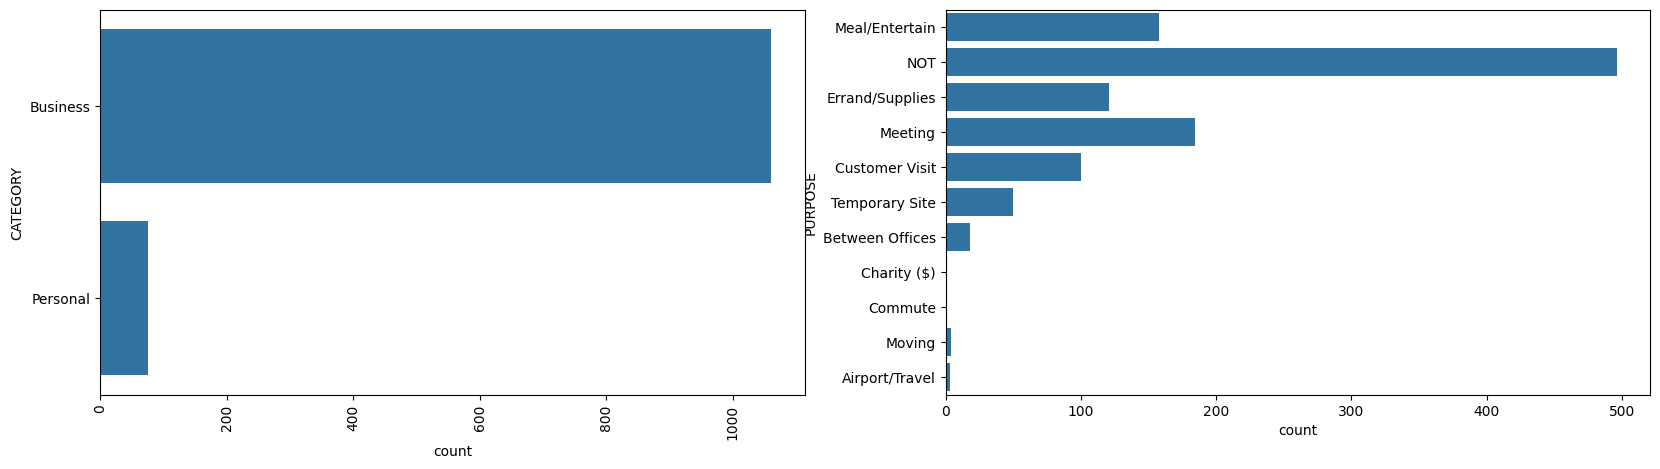

In [20]:
plt.figure(figsize=(20,5))

plt.subplot(1,2,1)

sns.countplot(df['CATEGORY'])
plt.xticks(rotation=90)

plt.subplot(1,2,2)
sns.countplot(df['PURPOSE'])

plt.show()

In the second graph we can see that purpose name "NOT" is very big but it is that value in which no any purpose was filled. So max purpose of users is Meal/Entertain and Meeting.

Bussiness category was used by max uber users to travelling.

# ______________________________________________________________________________________________

# Q-3) Which time max users like to travelling?

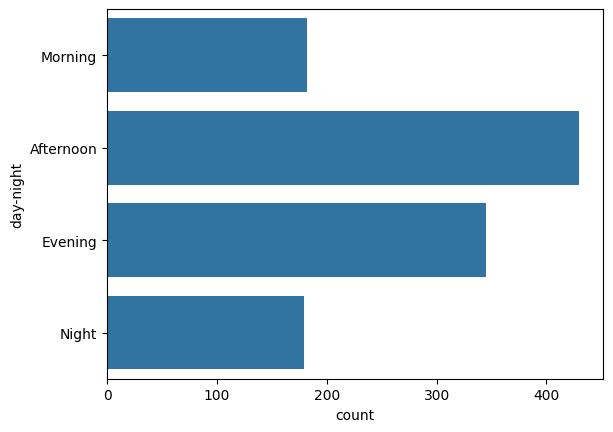

In [21]:
sns.countplot(df['day-night'])
plt.show()

Means Afternoon and envening time max user like to travelling.

# ___________________________________________________________________________________________________

# Q-4) How many users travels in which month ?

In [22]:
df.head(3)

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,date,time,day-night
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,Night
1,2016-02-01 01:25:00,2016-02-01 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-02-01,1.0,Morning
2,2016-02-01 20:25:00,2016-02-01 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-02-01,20.0,Night


In [23]:
# Adding a more column as month


df['MONTH'] = pd.DatetimeIndex(df['START_DATE']).month

month_label = {
    1.0: 'jan',
    2.0: 'Feb',
    3.0: 'Mar',
    4.0: 'Apr',
    5.0: 'May',
    6.0: 'June',
    7.0: 'July',
    8.0: 'Aug',
    9.0: 'Sept',
    10.0: 'Oct',
    11.0 : 'Nov',
    12.0: 'Dec'
}

In [24]:
df["MONTH"] = df.MONTH.map(month_label)
mon = df['MONTH'].value_counts().reindex([
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'June',
    'July', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec'
])

In [25]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,date,time,day-night,MONTH
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,Night,jan
1,2016-02-01 01:25:00,2016-02-01 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-02-01,1.0,Morning,Feb
2,2016-02-01 20:25:00,2016-02-01 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-02-01,20.0,Night,Feb
3,2016-05-01 17:31:00,2016-05-01 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-05-01,17.0,Evening,May
4,2016-06-01 14:42:00,2016-06-01 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-06-01,14.0,Afternoon,June


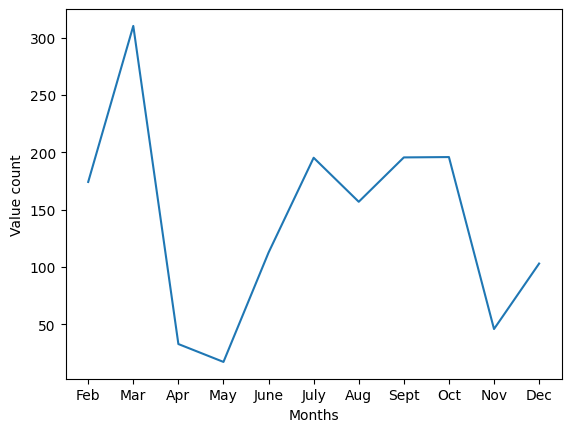

In [26]:
dp = pd.DataFrame({
    'MONTH': mon.index,
    'VALUE COUNT': df.groupby('MONTH', sort=False)['MILES'].max().reindex(mon.index).values
})

p = sns.lineplot(data=dp, x='MONTH', y='VALUE COUNT')

p.set(xlabel='Months', ylabel='Value count')

plt.show()

In [27]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,date,time,day-night,MONTH
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,Night,jan
1,2016-02-01 01:25:00,2016-02-01 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-02-01,1.0,Morning,Feb
2,2016-02-01 20:25:00,2016-02-01 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-02-01,20.0,Night,Feb
3,2016-05-01 17:31:00,2016-05-01 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-05-01,17.0,Evening,May
4,2016-06-01 14:42:00,2016-06-01 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-06-01,14.0,Afternoon,June


# _____________________________________________________________________________________________________

# Q-5) Which day more user travelling ?

In [28]:
# adding a new column 'day'

df['DAY'] = df.START_DATE.dt.weekday

day_label = {
    0: 'Mon',
    1: 'Tues',
    2: 'Wed',
    3: 'Thur',
    4: 'Fri',
    5: 'Sat',
    6: 'Sun'
}

df['DAY'] = df['DAY'].map(day_label)

In [29]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,date,time,day-night,MONTH,DAY
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,Night,jan,Fri
1,2016-02-01 01:25:00,2016-02-01 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-02-01,1.0,Morning,Feb,Mon
2,2016-02-01 20:25:00,2016-02-01 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-02-01,20.0,Night,Feb,Mon
3,2016-05-01 17:31:00,2016-05-01 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-05-01,17.0,Evening,May,Sun
4,2016-06-01 14:42:00,2016-06-01 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-06-01,14.0,Afternoon,June,Wed


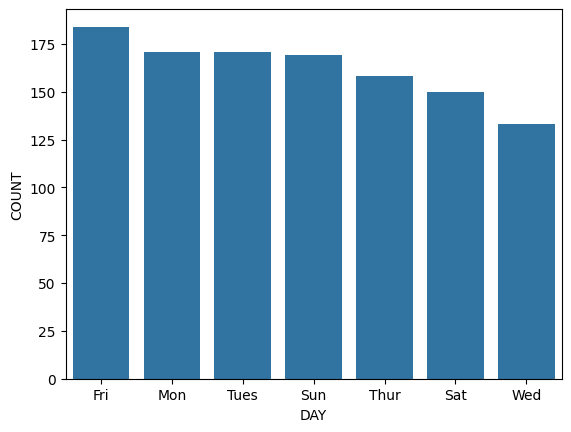

In [30]:
day_label = df.DAY.value_counts()
sns.barplot(x=day_label.index, y = day_label)
plt.xlabel("DAY")
plt.ylabel('COUNT')
plt.show()

In [ ]:
Ans.:  Means max users travel on the Friday.

# _____________________________________________________________________________________________________

# Ploting boxplot that are based on distanse (MILES)

In [31]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,date,time,day-night,MONTH,DAY
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,Night,jan,Fri
1,2016-02-01 01:25:00,2016-02-01 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-02-01,1.0,Morning,Feb,Mon
2,2016-02-01 20:25:00,2016-02-01 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-02-01,20.0,Night,Feb,Mon
3,2016-05-01 17:31:00,2016-05-01 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-05-01,17.0,Evening,May,Sun
4,2016-06-01 14:42:00,2016-06-01 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-06-01,14.0,Afternoon,June,Wed


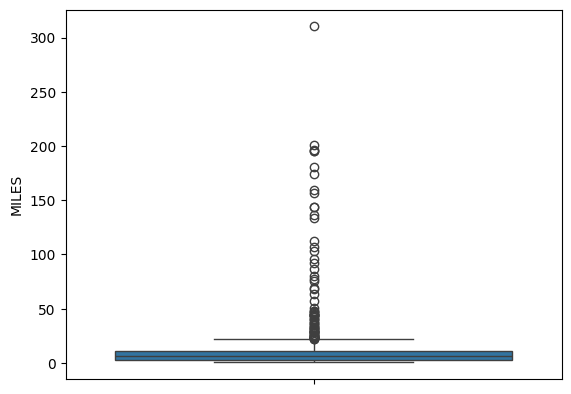

In [46]:
sns.boxplot(df['MILES'])
plt.show()






# Boxplot helps to find outliers

# In Boxplot , box represent the 50 percent of all and middle line represent the median

# This all boxplots represent the density of travel based on the distance

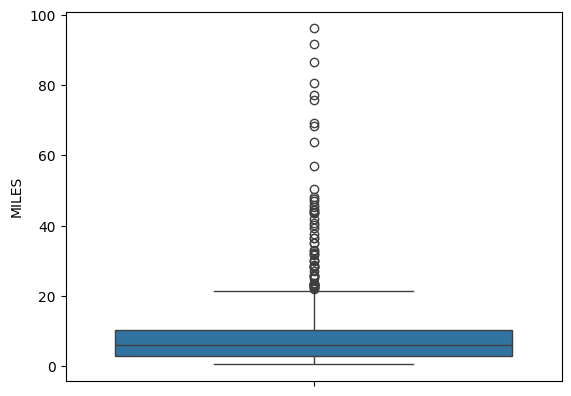

In [47]:
sns.boxplot(df[df['MILES']<100]['MILES'])     # Box plot under the 100 miles
plt.show()

# Boxplot Used to visualize the distribution of data and identify statistical outliers.

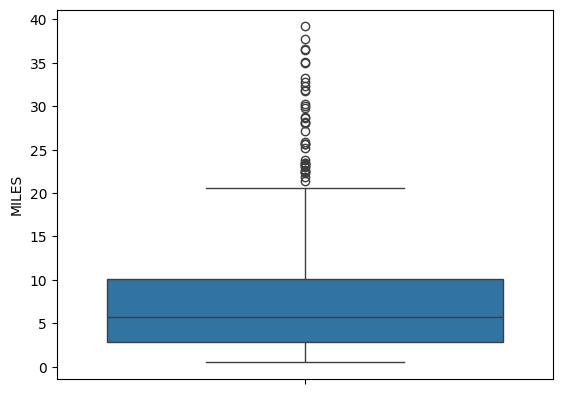

In [36]:
sns.boxplot(df[df['MILES']<40]['MILES'])
plt.show()

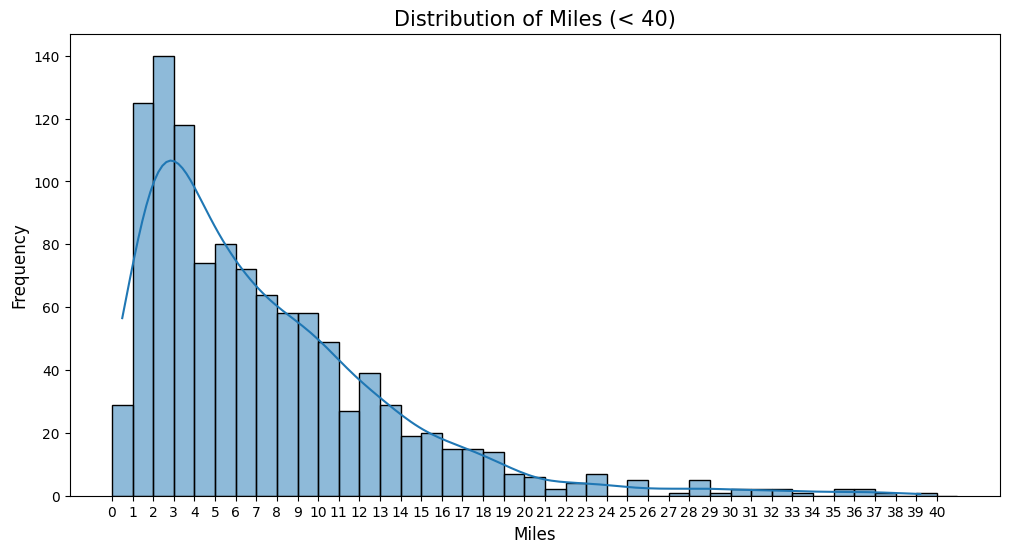

In [45]:
plt.figure(figsize=(12, 6))

sns.histplot(
    df[df['MILES'] < 40]['MILES'],
    bins=range(0, 42, 1),
    kde=True
)

plt.xlabel('Miles', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Miles (< 40)', fontsize=15)

plt.xticks(range(0, 41, 1))

plt.show()

# Distribution plot Ye batate hain ki different distance ranges mein kitni observations hain.


# Smooth curve: Upar jo smooth line hai, wo KDE (Kernel Density Estimate) hai. Ye data ki overall distribution ko smooth form mein show karti hai.